# Demo of using the results of cityseg

This notebook briefly shows how to load and use the results of the CitySeg segmentation. The segmentation mask results are stored in an hdf5 file, which can be manipulated using the provided CitySegData class. Below, we display the segmentation mask and check its shape.

In [1]:
from ivr_utils.cityseg_utils import CitySegData
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

#cityseg_test = Path(
    #"../data/outputs/segmentations/mask2f ormer-swin-large-cityscapes-semantic_step15/output_chopped_P43_fixedfps_mask2former-swin-large-cityscapes-semantic_step15_segmentation.h5"
#)
cityseg_test = Path(
    "/Users/yuqiliang/Documents/Github/data/cityseg_test/2025-03-12-test/mask2former-swin-large-cityscapes-semantic_step1/mask2former-swin-large-cityscapes-semantic_step1/P43_chopped_fixedfps_10s_mask2former-swin-large-cityscapes-semantic_step1_segmentation.h5"
)
cityseg_data = CitySegData.from_hdf(cityseg_test)
gaze_data_path = Path(
    "/Users/yuqiliang/Documents/Github/data/output/2025-04-01-test/processed/P43_chopped_fixedfps.npy"
)
gaze_data = np.load(gaze_data_path)  
np.set_printoptions(threshold=100)


In [3]:
matched_data = cityseg_data.match_gaze_with_masks(gaze_data, None)

In [5]:
print(matched_data[:20])

[[0 1935 1157 np.str_('MiradorSanNicolas1') np.int32(8)]
 [1 1935 1157 np.str_('MiradorSanNicolas1') np.int32(8)]
 [2 1935 1157 np.str_('MiradorSanNicolas1') np.int32(8)]
 [3 1936 1163 np.str_('MiradorSanNicolas1') np.int32(8)]
 [4 1936 1163 np.str_('MiradorSanNicolas1') np.int32(8)]
 [5 1936 1163 np.str_('MiradorSanNicolas1') np.int32(8)]
 [6 1919 1196 np.str_('MiradorSanNicolas1') np.int32(8)]
 [7 1919 1196 np.str_('MiradorSanNicolas1') np.int32(8)]
 [8 1919 1196 np.str_('MiradorSanNicolas1') np.int32(8)]
 [9 1919 1196 np.str_('MiradorSanNicolas1') np.int32(8)]
 [10 1867 1245 np.str_('MiradorSanNicolas1') np.int32(11)]
 [11 1867 1245 np.str_('MiradorSanNicolas1') np.int32(11)]
 [12 1867 1245 np.str_('MiradorSanNicolas1') np.int32(11)]
 [13 1867 1248 np.str_('MiradorSanNicolas1') np.int32(11)]
 [14 1867 1248 np.str_('MiradorSanNicolas1') np.int32(11)]
 [15 1867 1248 np.str_('MiradorSanNicolas1') np.int32(11)]
 [16 2179 1241 np.str_('MiradorSanNicolas1') np.int32(11)]
 [17 2179 1241 np

In [2]:
percentages = cityseg_data.calculate_percentage_of_mask(gaze_data)

0QUE MiradorSanNicolas1 1 0%
0QUE MiradorSanNicolas1 2 18%
0QUE MiradorSanNicolas1 3 0%
0QUE MiradorSanNicolas1 4 0%
0QUE MiradorSanNicolas1 5 2%
0QUE MiradorSanNicolas1 6 0%
0QUE MiradorSanNicolas1 7 0%
0QUE MiradorSanNicolas1 8 27%
0QUE MiradorSanNicolas1 9 0%
0QUE MiradorSanNicolas1 10 9%
0QUE MiradorSanNicolas1 11 40%
0QUE MiradorSanNicolas1 12 0%
0QUE MiradorSanNicolas1 13 0%
0QUE MiradorSanNicolas1 14 0%
0QUE MiradorSanNicolas1 15 0%
0QUE MiradorSanNicolas1 16 0%
0QUE MiradorSanNicolas1 17 0%
0QUE MiradorSanNicolas1 18 0%
1V BidderSt2 1 0%
1V BidderSt2 2 0%
1V BidderSt2 3 0%
1V BidderSt2 4 0%
1V BidderSt2 5 0%
1V BidderSt2 6 0%
1V BidderSt2 7 0%
1V BidderSt2 8 0%
1V BidderSt2 9 0%
1V BidderSt2 10 0%
1V BidderSt2 11 0%
1V BidderSt2 12 0%
1V BidderSt2 13 0%
1V BidderSt2 14 0%
1V BidderSt2 15 0%
1V BidderSt2 16 0%
1V BidderSt2 17 0%
1V BidderSt2 18 0%
5V PlazaBibRambla1 1 0%
5V PlazaBibRambla1 2 0%
5V PlazaBibRambla1 3 0%
5V PlazaBibRambla1 4 0%
5V PlazaBibRambla1 5 0%
5V PlazaBibRa

In [4]:
cityseg_data.hdf_file

<HDF5 file "P43_chopped_fixedfps_10s_mask2former-swin-large-cityscapes-semantic_step1_segmentation.h5" (mode r)>

In [4]:
# Get the segmentation mask
seg_mask = cityseg_data.get_segmentation_mask()

In [5]:
print(seg_mask[0])

[[ 8  8  8 ... 10 10 10]
 [ 8  8  8 ... 10 10 10]
 [ 8  8  8 ... 10 10 10]
 ...
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]]


In [9]:
seg_mask.shape
# n frames, n rows, n cols

(300, 2160, 3840)

In [3]:
cityseg_data.palette.shape
# n classes, rgb values

(20, 3)

In [4]:
cityseg_data.metadata

{'model_name': 'facebook/mask2former-swin-large-cityscapes-semantic',
 'original_video': 'output_chopped_P43_fixedfps.mp4',
 'palette': array([[128,  64, 128],
        [244,  35, 232],
        [ 70,  70,  70],
        [102, 102, 156],
        [190, 153, 153],
        [153, 153, 153],
        [250, 170,  30],
        [220, 220,   0],
        [107, 142,  35],
        [152, 251, 152],
        [ 70, 130, 180],
        [220,  20,  60],
        [255,   0,   0],
        [  0,   0, 142],
        [  0,   0,  70],
        [  0,  60, 100],
        [  0,  80, 100],
        [  0,   0, 230],
        [119,  11,  32],
        [  0,   0,   0]], dtype=uint8),
 'label_ids': {'0': 'road',
  '1': 'sidewalk',
  '2': 'building',
  '3': 'wall',
  '4': 'fence',
  '5': 'pole',
  '6': 'traffic light',
  '7': 'traffic sign',
  '8': 'vegetation',
  '9': 'terrain',
  '10': 'sky',
  '11': 'person',
  '12': 'rider',
  '13': 'car',
  '14': 'truck',
  '15': 'bus',
  '16': 'train',
  '17': 'motorcycle',
  '18': 'bicycle

In [5]:
seg_mask[0]

array([[8, 8, 8, ..., 8, 8, 8],
       [8, 8, 8, ..., 8, 8, 8],
       [8, 8, 8, ..., 8, 8, 8],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], dtype=int32)

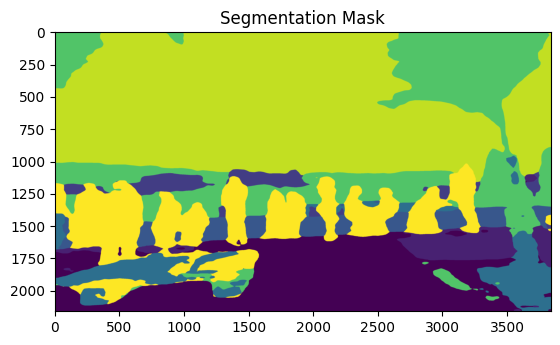

In [17]:
# Display the segmentation mask
plt.imshow(seg_mask[0])
plt.title("Segmentation Mask")
plt.axis("on")
plt.show()
